### Етап 1: Підготовка даних, трансформація зображень та створення DataLoader

Першим кроком у побудові будь-якої нейронної мережі, особливо в задачах комп'ютерного зору (Computer Vision), є правильна підготовка та стандартизація даних. Зображення можуть мати різний розмір та пропорції, тому їх необхідно звести до єдиного математичного формату. У цьому блоці виконуються такі ключові дії:

1. **Імпорт бібліотек та фіксація генераторів випадкових чисел:** Завантаження модулів PyTorch, інструментів `torchvision` (для роботи із зображеннями) та `matplotlib`. Використання `torch.manual_seed(42)` гарантує відтворюваність результатів експериментів — при повторному запуску коду розбиття на вибірки та початкові ваги мережі будуть ідентичними.

2. **Налаштування конвеєра трансформацій (`transforms.Compose`):** Для коректної роботи згорткової нейромережі (CNN), а також для подальшого використання підходу Transfer Learning, кожне зображення проходить три етапи обробки:
   * `Resize((224, 224))` — жорстке приведення всіх зображень до єдиного стандарту 224x224 пікселі, чого вимагають архітектури на кшталт ResNet.
   * `ToTensor()` — конвертація зображення у тензор PyTorch та стиснення значень пікселів із діапазону [0, 255] у діапазон [0.0, 1.0].
   * `Normalize(...)` — стандартизація трьох колірних каналів (RGB). Використовуються константи середнього (`mean`) та дисперсії (`std`), вираховані на гігантському датасеті ImageNet. Це усуває проблему коваріативного зсуву на вході та є обов'язковою умовою для коректної роботи попередньо навчених моделей.

3. **Завантаження датасету (`datasets.ImageFolder`):** Використовується оптимізований клас PyTorch, який автоматично сканує директорію, визначає кількість класів (за назвами вкладених папок) і призначає кожному зображенню відповідну числову мітку.

4. **Розбиття вибірки (`random_split`):** Весь масив зображень випадковим чином ділиться на дві незалежні частини:
   * **Тренувальна (80%)** — використовується для обчислення градієнтів та налаштування фільтрів згорткової мережі.
   * **Валідаційна (20%)** — відкладена вибірка для об'єктивної оцінки точності та роботи механізму Early Stopping.

5. **Організація пакетного завантаження (`DataLoader`):** Створення ітераторів, які автоматично нарізають датасет на батчі (міні-пакети) розміром `batch_size = 32`. 
   * Для `train_loader` активовано `shuffle=True`, що змушує алгоритм перемішувати картинки перед кожною епохою. Це запобігає запам'ятовуванню мережею послідовності даних і стабілізує градієнтний спуск. 
   * Для `val_loader` перемішування вимкнено (`shuffle=False`), оскільки під час іспиту (перевірки) оновлення ваг не відбувається.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

data_dir = 'D:\\CI\\CI_labs\\L5\\variant4'
batch_size = 32
img_size = 224

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = full_dataset.classes

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(class_names)
print(len(train_dataset))
print(len(val_dataset))

inputs, classes = next(iter(train_loader))
print(inputs.shape)
print(classes.shape)

['Naruto', 'One Piece', 'Parasyte', 'Princess Tutu', 'Puella Magi Madoka Magica', 'ReLife', 'ReZero', 'Redline', 'Revolutionary Girl Utena', 'Rocky Joe 2', 'Romeo and the Black Brothers', 'Rurouni Kenshin', 'Sain Seiya', 'Saint Seiya', 'Samurai Champloo', 'Samurai X', 'Sekai Ichi Hatsukoi', 'Sekaiichi Hatsukoi', 'Shelter', 'Shirobako']
6006
1502
torch.Size([32, 3, 224, 224])
torch.Size([32])


### Етап 2: Проєктування та ініціалізація власної згорткової нейронної мережі (CNN)

На цьому етапі створюється базова архітектура згорткової нейронної мережі з нуля. Відповідно до вимог завдання, мережа побудована на основі трьох послідовних згорткових блоків та використовує сучасний підхід усереднення просторових ознак для зменшення складності моделі. У цьому блоці реалізовано наступні архітектурні концепції:

1. **Ієрархія згорткових блоків (`nn.Sequential`):** Мережа містить три блоки виділення ознак, які послідовно збільшують кількість карт ознак (16 → 32 → 64). Кожен наступний блок аналізує все більш складні та абстрактні патерни на основі інформації з попереднього шару.

2. **Внутрішня структура блоку (Conv → BatchNorm → ReLU → MaxPool):** 
   Кожен блок має суворо визначену послідовність шарів:
   * `Conv2d` — виконує операцію згортки з ядром 3x3 (`kernel_size=3`) та збереженням розмірності матриці (`padding=1`). Цей шар відповідає за розпізнавання локальних ознак (контурів, текстур, форм).
   * `BatchNorm2d` — виконує пакетну нормалізацію активацій. Це стабілізує розподіл даних всередині мережі, вирішує проблему внутрішнього коваріативного зсуву та дозволяє використовувати більший крок навчання.
   * `ReLU` — функція активації, яка вносить нелінійність у модель, пропускаючи лише позитивні сигнали і зануляючи від'ємні.
   * `MaxPool2d` — виконує операцію субдискретизації (зменшення розміру карти ознак удвічі завдяки `stride=2`), вибираючи найважливіші (максимальні) значення. Це робить мережу стійкою до незначних зсувів об'єкта на зображенні.

3. **Global Average Pooling (GAP) замість Flatten:** 
   Перед передачею даних у фінальний класифікатор використовується `AdaptiveAvgPool2d((1, 1))`. Замість того, щоб розгортати останню багатовимірну карту ознак у гігантський одновимірний вектор (як це робить Flatten), GAP обчислює єдине середнє значення для кожної з 64 карт. Це кардинально зменшує розмірність даних перед повнозв'язним шаром.

4. **Класифікатор (`nn.Linear`):** Фінальний повнозв'язний шар, який приймає стиснутий вектор із 64 усереднених ознак та виконує лінійну трансформацію у вектор вихідних ймовірностей (логітів) відповідно до кількості класів у датасеті (`num_classes`).

5. **Аналіз оптимізації кількості параметрів:** Код містить функцію `count_parameters`, яка підраховує кількість вагових коефіцієнтів моделі (`requires_grad=True`). Додатковий математичний блок розраховує гіпотетичну кількість параметрів, якби мережа використовувала операцію Flatten (де 64 карти ознак розміром 28x28 пікселів розгорталися б у вектор довжиною понад 50 тисяч елементів). Виведення цих двох значень наочно доводить, що перехід до GAP зменшує загальну кількість параметрів на сотні тисяч, що значно знижує обчислювальне навантаження та ризик перенавчання моделі.

In [2]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_classes = len(class_names)
model_custom = CustomCNN(num_classes)

params_gap = count_parameters(model_custom)

flatten_features = 64 * 28 * 28
params_flatten_fc = (flatten_features * num_classes) + num_classes
params_flatten_total = params_gap - (64 * num_classes + num_classes) + params_flatten_fc

print(params_gap)
print(params_flatten_total)

25108
1027348


### Етап 3: Реалізація універсального циклу навчання (Training Loop) з механізмами регуляризації

На цьому етапі створюється головний обчислювальний "двигун" — функція `train_model`. Вона розроблена як універсальний інструмент, який буде використовуватися для всіх трьох експериментів у цій лабораторній роботі (навчання власної CNN, Feature Extraction та Fine-Tuning). Замість базового циклу, тут реалізовано повноцінний пайплайн із сучасними механізмами контролю навчання:

1. **Розподіл на фази (Training та Validation):** Кожна епоха суворо розділена на дві частини. 
   * У фазі `train` викликається метод `model.train()`, який активує оновлення внутрішньої статистики в шарах `BatchNorm2d` та вмикає `Dropout` (якщо він присутній в архітектурі). 
   * У фазі `val` викликається `model.eval()`, що переводить мережу в режим інференсу (тестування) — шари нормалізації використовують глобальну накопичену статистику, а ваги фіксуються.

2. **Оптимізація пам'яті та обчислень (Контекстний менеджер градієнтів):**
   Використання конструкції `with torch.set_grad_enabled(phase == 'train'):` є критично важливим архітектурним рішенням. Під час валідації програма повністю вимикає побудову обчислювального графа (Autograd). Це дозволяє звільнити до 50% відеопам'яті (VRAM) та значно пришвидшити прохід валідаційної вибірки.

3. **Керування градієнтним спуском:** 
   У тренувальній фазі реалізовано класичний цикл оптимізації:
   * `optimizer.zero_grad()` — обов'язкове очищення накопичених градієнтів від попереднього міні-батчу (інакше вони будуть сумуватися).
   * `loss.backward()` — зворотне поширення помилки (Backpropagation) для обчислення вектора градієнтів.
   * `optimizer.step()` — фізичне оновлення вагових коефіцієнтів моделі на основі розрахованих градієнтів та обраного кроку навчання.

4. **Механізм Early Stopping та Checkpointing:** 
   Щоб запобігти перенавчанню (overfitting), коли модель починає просто "зазубрювати" тренувальні дані, впроваджено лічильник терпіння (`patience=5`). Якщо точність на валідації (`val_acc`) не покращується протягом 5 епох поспіль, цикл примусово переривається. При цьому алгоритм постійно створює резервну копію ваг (`copy.deepcopy(model.state_dict())`) у точці глобального максимуму валідаційної точності. Наприкінці роботи функції саме ці, найкращі ваги, повертаються у модель.

5. **Адаптивне планування кроку навчання (Scheduler):**
   В кінці кожної валідаційної фази викликається `scheduler.step(epoch_loss)`. Це дозволяє динамічно зменшувати `learning rate`, якщо модель потрапляє на "плато" функції втрат, що допомагає оптимізатору точніше знайти глобальний мінімум.

6. **Трекінг метрик (History Logging):**
   Усі розраховані значення функції втрат (Loss) та точності (Accuracy) для обох фаз зберігаються у словник `history`. Цей масив даних є необхідним для подальшої візуалізації динаміки навчання та побудови порівняльних графіків між різними архітектурами.

In [3]:
import time
import copy
import torch

def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=25, patience=5, device='cpu'):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                if scheduler is not None:
                    scheduler.step(epoch_loss)
                
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    
        if epochs_no_improve >= patience:
            print('Early stopping')
            break
            
        print()
        
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    
    model.load_state_dict(best_model_wts)
    return model, history

### Етап 4: Ініціалізація гіперпараметрів та запуск навчання власної CNN

На цьому етапі відбувається конфігурація математичного апарату оптимізації та безпосередній запуск тренування побудованої з нуля нейромережі. Код налаштовує середовище виконання та задає ключові гіперпараметри для ефективного навчання:

1. **Апаратне прискорення (Device Configuration):**
   Конструкція `torch.device("cuda:0" if torch.cuda.is_available() else "cpu")` забезпечує автоматичний вибір обчислювального пристрою. Якщо в системі доступна відеокарта (GPU) із підтримкою CUDA, архітектура моделі переноситься в її пам'ять (`model_custom.to(device)`). Це дозволяє виконувати паралельні обчислення тензорів, що пришвидшує процес тренування в десятки разів порівняно з класичним центральним процесором (CPU).

2. **Функція втрат (Criterion / Loss Function):**
   Використовується об'єкт `nn.CrossEntropyLoss()`. Цей критерій є золотим стандартом для задач багатокласової класифікації. Він об'єднує в собі функцію Softmax (яка конвертує сирі вихідні логіти у розподіл ймовірностей) та розрахунок перехресної ентропії. Алгоритм мінімізує логарифмічну відстань між передбаченим розподілом та фактичним класом зображення.

3. **Оптимізатор (Adam):**
   
   Для оновлення вагових коефіцієнтів застосовується алгоритм адаптивної оцінки моментів `optim.Adam` із початковим кроком навчання `lr=0.001`. На відміну від стандартного стохастичного градієнтного спуску (SGD), Adam розраховує індивідуальні швидкості оновлення для кожного параметра, аналізуючи історію та дисперсію градієнтів, що забезпечує значно швидшу та стабільнішу збіжність моделі.

4. **Адаптивне планування кроку навчання (LR Scheduler):**
   Для запобігання застряганню градієнтного спуску в локальних мінімумах налаштовано `ReduceLROnPlateau`. Він моніторить динаміку похибки на валідації (`mode='min'`). Якщо помилка не зменшується протягом 3 епох (`patience=3`), планувальник зменшує поточний крок навчання вдвічі (`factor=0.5`). Мікрокроки на фінальних етапах дозволяють мережі філігранно досягти оптимальної точки, не "перестрибуючи" її.

5. **Виконання навчального циклу:**
   Викликається розроблена раніше універсальна функція `train_model`, до якої передаються оптимізатор, планувальник та підготовлені `DataLoader`-и. Ліміт епох встановлено на 25 (`num_epochs=25`), проте завдяки вбудованому механізму ранньої зупинки (Early Stopping з `patience=5`), цикл може завершитися швидше, щойно модель досягне свого піку узагальнення. На виході формується натренована модель та історія метрик `history_custom` для подальшої побудови графіків.

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_custom = model_custom.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_custom = optim.Adam(model_custom.parameters(), lr=0.001)

scheduler_custom = optim.lr_scheduler.ReduceLROnPlateau(optimizer_custom, mode='min', factor=0.5, patience=3)

print("Training Custom CNN...")
model_custom, history_custom = train_model(
    model=model_custom,
    criterion=criterion,
    optimizer=optimizer_custom,
    scheduler=scheduler_custom,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=25,
    patience=5,
    device=device
)

Training Custom CNN...
Epoch 0/24
----------
train Loss: 2.7616 Acc: 0.1602
val Loss: 2.6693 Acc: 0.1758

Epoch 1/24
----------
train Loss: 2.6127 Acc: 0.2125
val Loss: 2.5616 Acc: 0.2217

Epoch 2/24
----------
train Loss: 2.5378 Acc: 0.2266
val Loss: 2.5267 Acc: 0.2237

Epoch 3/24
----------
train Loss: 2.4794 Acc: 0.2368
val Loss: 2.4774 Acc: 0.2377

Epoch 4/24
----------
train Loss: 2.4417 Acc: 0.2522
val Loss: 2.4083 Acc: 0.2636

Epoch 5/24
----------
train Loss: 2.4008 Acc: 0.2636
val Loss: 2.4346 Acc: 0.2623

Epoch 6/24
----------
train Loss: 2.3634 Acc: 0.2835
val Loss: 2.4356 Acc: 0.2590

Epoch 7/24
----------
train Loss: 2.3481 Acc: 0.2864
val Loss: 2.3684 Acc: 0.2617

Epoch 8/24
----------
train Loss: 2.3152 Acc: 0.2915
val Loss: 2.3691 Acc: 0.2603

Epoch 9/24
----------
train Loss: 2.2909 Acc: 0.3019
val Loss: 2.3364 Acc: 0.2730

Epoch 10/24
----------
train Loss: 2.2838 Acc: 0.2969
val Loss: 2.3223 Acc: 0.2816

Epoch 11/24
----------
train Loss: 2.2530 Acc: 0.3105
val Loss:

### Етап 5: Застосування Transfer Learning (Стратегія Feature Extraction)

На цьому етапі реалізується перший підхід до перенесення знань (Transfer Learning) — метод **Feature Extraction (Виділення ознак)**. Замість того, щоб навчати глибоку мережу з нуля, ми використовуємо "досвід" моделі, яка вже навчалася на мільйонах зображень. Основні архітектурні кроки цього блоку:



1. **Завантаження базової моделі (ResNet18):** Використовується архітектура `resnet18` із завантаженням попередньо навчених ваг (`weights=models.ResNet18_Weights.DEFAULT`). Ця модель попередньо тренувалася на гігантському датасеті ImageNet (1000 класів). Завдяки цьому її згорткові шари вже вміють ідеально розпізнавати базові візуальні патерни: контури, градієнти світла, складні текстури та геометричні форми.

2. **Заморозка ваг (Freezing):**
   Цикл `for param in model_fe.parameters(): param.requires_grad = False` є ключовим для стратегії Feature Extraction. Він проходить по всіх мільйонах параметрів базової мережі та забороняє їх оновлення (вимикає обчислення градієнтів). Це означає, що під час навчання базова частина ResNet18 працюватиме виключно як статичний екстрактор: вона прийматиме зображення і перетворюватиме його на вектор із 512 високорівневих ознак. Це колосально економить обчислювальні ресурси.

3. **Адаптація класифікатора (Заміна "мозку"):**
   Оригінальний фінальний шар моделі (`model_fe.fc`) був налаштований на 1000 класів ImageNet. Ми зчитуємо кількість його вхідних ознак (`num_ftrs = 512`) і замінюємо його на новий повнозв'язний шар `nn.Linear(num_ftrs, num_classes)`. Цей новий шар ініціалізується з випадковими вагами, і його градієнти за замовчуванням увімкнені.

4. **Локальна оптимізація (Спрямований Adam):**
   Критично важливий рядок — ініціалізація оптимізатора: `optimizer_fe = optim.Adam(model_fe.fc.parameters(), lr=0.001)`. На відміну від попереднього експерименту, ми передаємо оптимізатору параметри **лише одного фінального шару** (`model_fe.fc.parameters()`). Мережа буде вчитися лише тому, як правильно комбінувати 512 готових ознак для класифікації конкретних стилів аніме.

5. **Виконання навчального циклу:**
   Сконфігурована модель передається в універсальну функцію `train_model`. Оскільки навчається лише один шар (близько 10 тисяч параметрів замість 11 мільйонів), розрахунки відбуваються значно швидше, а модель зазвичай демонструє високу точність уже з перших епох.

In [5]:
import torchvision.models as models

model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_fe.parameters():
    param.requires_grad = False

num_ftrs = model_fe.fc.in_features
model_fe.fc = nn.Linear(num_ftrs, num_classes)

model_fe = model_fe.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_fe = optim.Adam(model_fe.fc.parameters(), lr=0.001)

scheduler_fe = optim.lr_scheduler.ReduceLROnPlateau(optimizer_fe, mode='min', factor=0.5, patience=3)

print("Training Feature Extraction Model...")
model_fe, history_fe = train_model(
    model=model_fe,
    criterion=criterion,
    optimizer=optimizer_fe,
    scheduler=scheduler_fe,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=25,
    patience=5,
    device=device
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 9.64MB/s]


Training Feature Extraction Model...
Epoch 0/24
----------
train Loss: 2.3748 Acc: 0.2884
val Loss: 1.8629 Acc: 0.4474

Epoch 1/24
----------
train Loss: 1.7221 Acc: 0.4872
val Loss: 1.6227 Acc: 0.4887

Epoch 2/24
----------
train Loss: 1.5259 Acc: 0.5291
val Loss: 1.5181 Acc: 0.5033

Epoch 3/24
----------
train Loss: 1.4149 Acc: 0.5568
val Loss: 1.5283 Acc: 0.5220

Epoch 4/24
----------
train Loss: 1.3548 Acc: 0.5728
val Loss: 1.4299 Acc: 0.5253

Epoch 5/24
----------
train Loss: 1.2769 Acc: 0.5977
val Loss: 1.4024 Acc: 0.5366

Epoch 6/24
----------
train Loss: 1.2357 Acc: 0.6052
val Loss: 1.4417 Acc: 0.5306

Epoch 7/24
----------
train Loss: 1.2060 Acc: 0.6147
val Loss: 1.4098 Acc: 0.5200

Epoch 8/24
----------
train Loss: 1.1786 Acc: 0.6319
val Loss: 1.3970 Acc: 0.5300

Epoch 9/24
----------
train Loss: 1.1352 Acc: 0.6352
val Loss: 1.4061 Acc: 0.5346

Epoch 10/24
----------
train Loss: 1.1220 Acc: 0.6342
val Loss: 1.4116 Acc: 0.5246
Early stopping
Training complete in 29m 2s
Best va

### Етап 6: Застосування Transfer Learning (Стратегія Fine-Tuning)

На цьому етапі реалізується складніший, але зазвичай більш результативний підхід до перенесення знань — **Fine-Tuning (Донавчання або Тонке налаштування)**. На відміну від Feature Extraction, де згорткова база залишалася абсолютно статичною, тут ми дозволяємо моделі адаптувати свої найглибші фільтри безпосередньо під візуальну специфіку нового датасету.

Основні архітектурні кроки цього етапу:

1. **Глобальна заморозка як базовий стан:**
   Аналогічно до попереднього етапу, завантажується попередньо навчена ResNet18, і всі її параметри глобально переводяться в режим `requires_grad = False`. Це створює "безпечний" фундамент, щоб не зруйнувати базові візуальні фільтри мережі випадковими градієнтами на початку навчання.

2. **Точкова розморозка високорівневих шарів (`layer4`):**
   
   За допомогою ітерації по архітектурі (`model.named_children()`) алгоритм знаходить останній згортковий блок — `layer4`, і вмикає для його параметрів розрахунок градієнтів (`requires_grad = True`). 
   * **Математичний/логічний сенс:** Перші шари мережі розпізнають універсальні примітиви (горизонтальні/вертикальні градієнти, плями кольору), які є однаковими і для фотографій, і для мальованого аніме. Їх перенавчати не потрібно. Натомість останній блок `layer4` відповідає за збирання цих примітивів у складні об'єкти (морди тварин, колеса). Розморозивши його, ми змушуємо мережу забути об'єкти з ImageNet і навчитися складати з ліній специфічні для аніме очі, зачіски чи елементи одягу.

3. **Заміна класифікатора:**
   Як і раніше, фінальний шар замінюється на `nn.Linear(num_ftrs, num_classes)`, який автоматично ініціалізується з `requires_grad = True` та готовий до навчання.

4. **Фільтрація параметрів для оптимізатора:**
   Щоб оптимізатор Adam коректно працював і не видавав помилок при спробі оновити заморожені ваги, використовується лямбда-функція: `filter(lambda p: p.requires_grad, model_ft.parameters())`. Таким чином, в оптимізатор потрапляють лише розморожений `layer4` та новий класифікатор.

5. **Зменшений крок навчання (Micro-stepping):**
   
   Зверніть увагу на параметр `lr=0.0001` (вдесятеро менший, ніж у попередніх експериментах). Оскільки `layer4` вже містить хороші, хоч і трохи "чужі" ваги, агресивний градієнтний спуск (великий крок) міг би повністю зруйнувати ці корисні значення (явище Catastrophic Forgetting). Малий крок навчання дозволяє виконувати "ювелірне" підлаштування фільтрів.

6. **Навчальний цикл:**
   Модель передається в універсальну функцію `train_model`. Цей процес потребуватиме більше часу та відеопам'яті, ніж Feature Extraction, оскільки тепер алгоритм Backpropagation змушений розраховувати градієнти не лише для останнього шару, а й для всього блоку `layer4`.

In [6]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_ft.parameters():
    param.requires_grad = False

for name, child in model_ft.named_children():
    if name in ['layer4']:
        for param in child.parameters():
            param.requires_grad = True

num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, num_classes)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=0.0001)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=3)

print("Training Fine-Tuning Model...")
model_ft, history_ft = train_model(
    model=model_ft,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=25,
    patience=5,
    device=device
)

Training Fine-Tuning Model...
Epoch 0/24
----------
train Loss: 1.7798 Acc: 0.4624
val Loss: 1.1618 Acc: 0.5826

Epoch 1/24
----------
train Loss: 0.8010 Acc: 0.7512
val Loss: 0.9638 Acc: 0.6318

Epoch 2/24
----------
train Loss: 0.4139 Acc: 0.8745
val Loss: 0.9380 Acc: 0.6491

Epoch 3/24
----------
train Loss: 0.2376 Acc: 0.9129
val Loss: 0.9506 Acc: 0.6318

Epoch 4/24
----------
train Loss: 0.1747 Acc: 0.9234
val Loss: 0.9533 Acc: 0.6591

Epoch 5/24
----------
train Loss: 0.1518 Acc: 0.9231
val Loss: 0.9603 Acc: 0.6491

Epoch 6/24
----------
train Loss: 0.1345 Acc: 0.9296
val Loss: 0.9991 Acc: 0.6511

Epoch 7/24
----------
train Loss: 0.1124 Acc: 0.9342
val Loss: 1.0002 Acc: 0.6471

Epoch 8/24
----------
train Loss: 0.1059 Acc: 0.9302
val Loss: 1.0318 Acc: 0.6545

Epoch 9/24
----------
train Loss: 0.1045 Acc: 0.9342
val Loss: 1.0429 Acc: 0.6451
Early stopping
Training complete in 33m 36s
Best val Acc: 0.659121


### Етап 7: Порівняльний аналіз моделей, візуалізація метрик та оцінка якості класифікації

Заключний етап лабораторної роботи присвячений об'єктивному оцінюванню результатів усіх трьох експериментів: власної CNN, стратегії Feature Extraction та стратегії Fine-Tuning. Замість того, щоб спиратися лише на фінальні цифри, тут застосовується комплексний підхід до візуалізації динаміки навчання та глибинного аналізу помилок найкращої моделі.

Цей блок реалізує наступні аналітичні інструменти:

1. **Побудова кривих навчання (Learning Curves):** 
   За допомогою бібліотеки `matplotlib` генерується спільний графік із двома підграфіками (Subplots):
   * **Графік Validation Loss:** Дозволяє наочно порівняти здатність моделей до узагальнення. Чим нижче опускається лінія, тим менша похибка. Аналіз форми цієї кривої допомагає виявити момент перенавчання (якщо лінія після стабільного падіння починає зростати).
   * **Графік Validation Accuracy:** Показує абсолютну точність моделей на даних, які вони ніколи не бачили під час тренування. Накладання трьох графіків дозволяє емпірично довести або спростувати перевагу методів Transfer Learning над архітектурою, написаною з нуля.

2. **Підготовка до чистого інференсу (Evaluation Mode):**
   Виклик `model_ft.eval()` гарантує, що мережа переходить у суворий режим тестування (вимикаються регуляризаційні механізми на кшталт Dropout, а BatchNorm фіксує свою статистику). Контекстний менеджер `with torch.no_grad():` повністю відключає механізм Autograd (обчислення похідних). Це звільняє оперативну пам'ять і значно прискорює прямий прохід тензорів через мережу.

3. **Агрегація прогнозів:**
   Алгоритм проходить через увесь `val_loader`, виконує передбачення (`outputs = model_ft(inputs)`), та за допомогою `torch.max` вибирає індекс класу з найвищою ймовірністю. Важливим інженерним кроком є виклик `.cpu().numpy()`, який переносить тензори з пам'яті відеокарти (GPU) в оперативну пам'ять процесора та конвертує їх у масиви NumPy, сумісні з аналітичними функціями бібліотеки `scikit-learn`.

4. **Матриця помилок (Confusion Matrix):**
   
   Для глибокого розуміння "мислення" нейромережі будується Матриця помилок, яка візуалізується за допомогою `seaborn.heatmap`. 
   * **Головна діагональ:** Показує кількість правильних класифікацій (True Positives) для кожного окремого аніме.
   * **Позадіагональні елементи:** Вказують на помилки першого та другого роду (Хибні спрацьовування та Пропуски). Візуалізація кольором (cmap='Blues') дозволяє миттєво знайти так звані "аномалії класифікації" — випадки, коли нейромережа систематично плутає два конкретних аніме між собою (що може бути спричинено схожою стилістикою рисовки або однаковою кольоровою гамою персонажів). Це дає вичерпну інформацію для подальшого вдосконалення датасету або архітектури моделі.

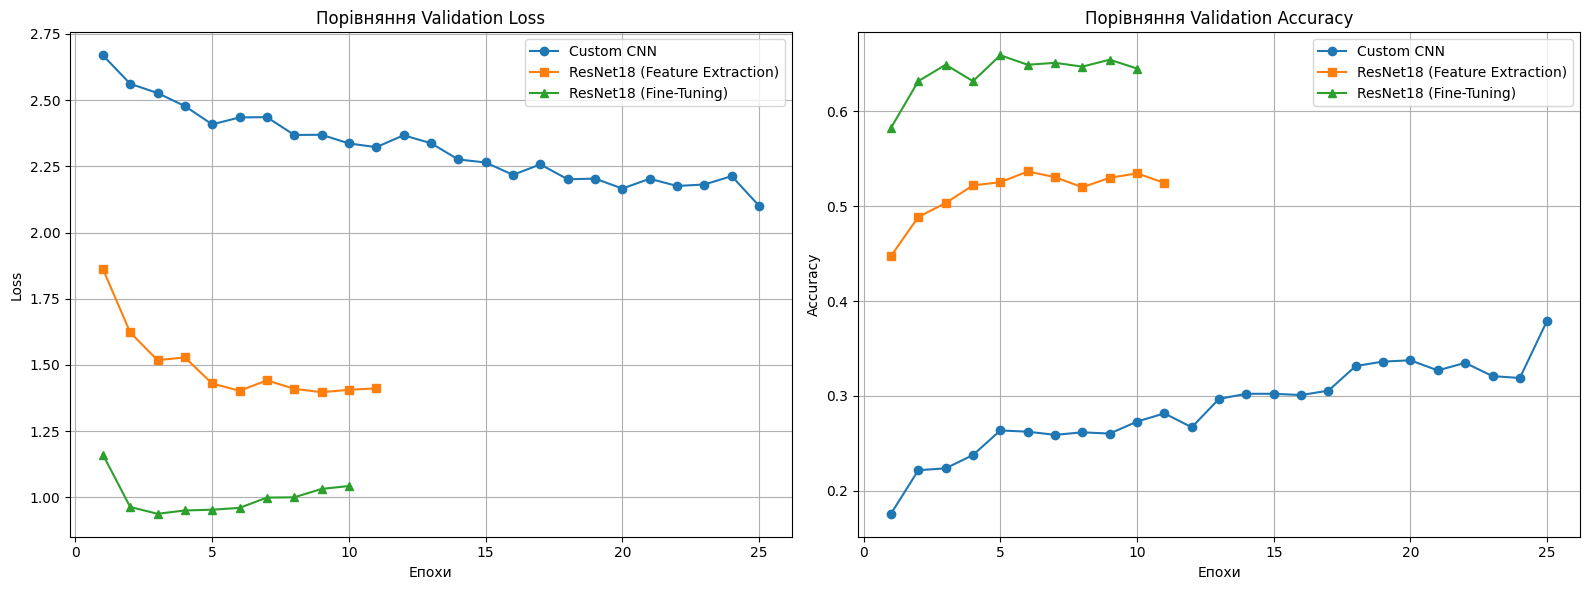

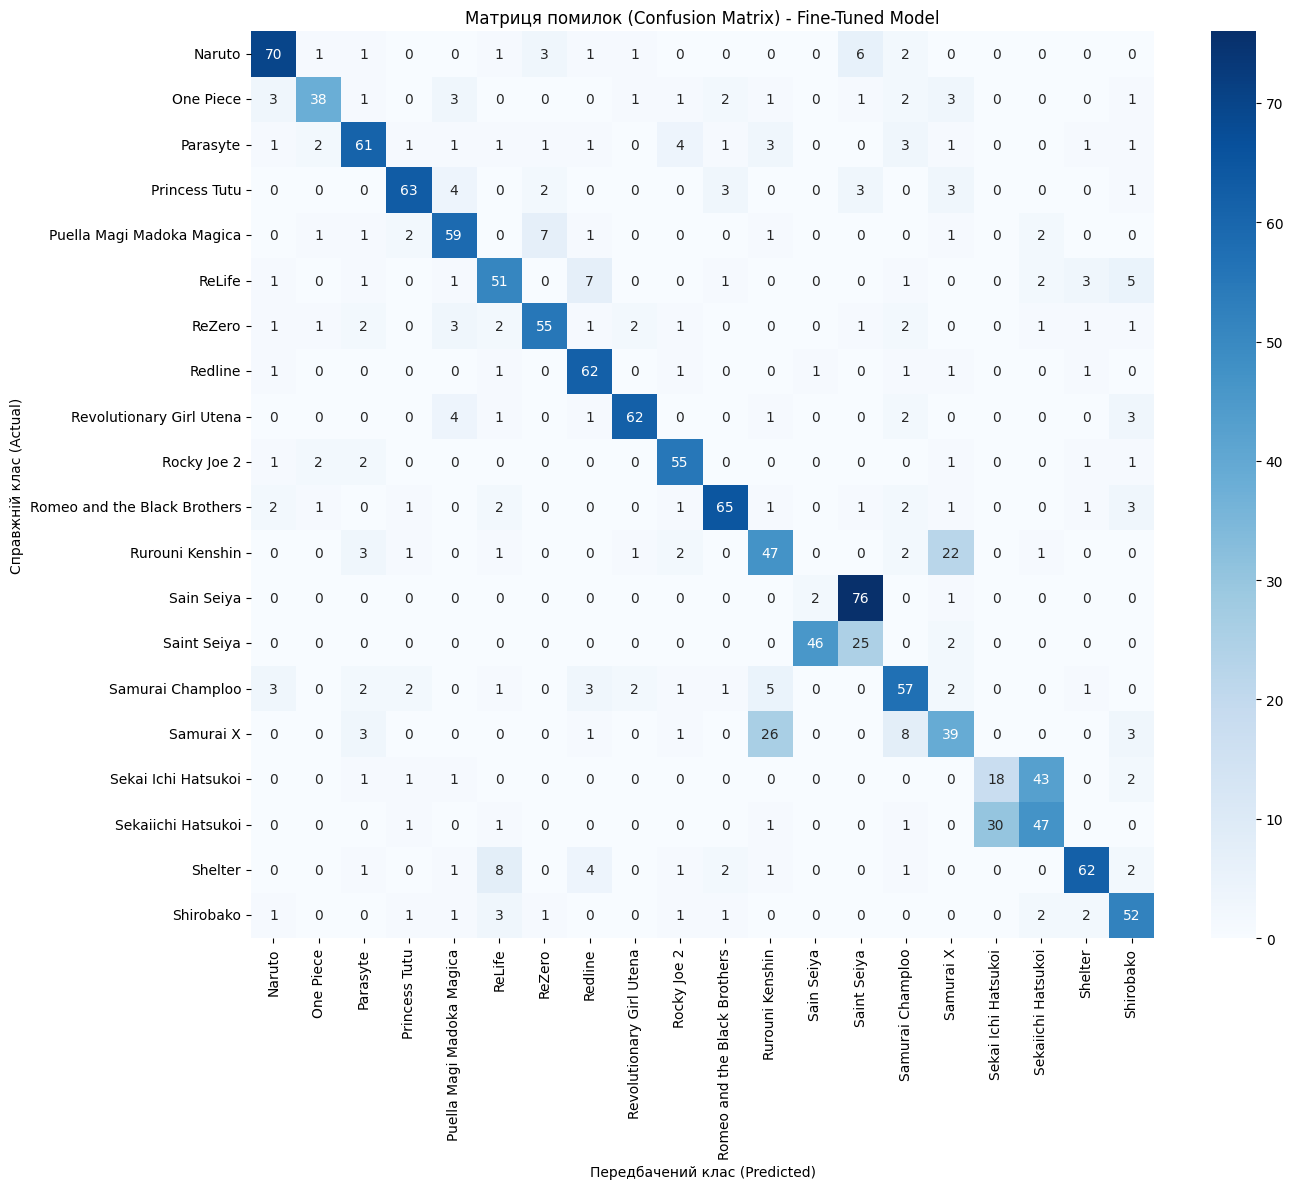

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

epochs_custom = range(1, len(history_custom['val_loss']) + 1)
epochs_fe = range(1, len(history_fe['val_loss']) + 1)
epochs_ft = range(1, len(history_ft['val_loss']) + 1)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_custom, history_custom['val_loss'], label='Custom CNN', marker='o')
plt.plot(epochs_fe, history_fe['val_loss'], label='ResNet18 (Feature Extraction)', marker='s')
plt.plot(epochs_ft, history_ft['val_loss'], label='ResNet18 (Fine-Tuning)', marker='^')
plt.title('Порівняння Validation Loss')
plt.xlabel('Епохи')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_custom, history_custom['val_acc'], label='Custom CNN', marker='o')
plt.plot(epochs_fe, history_fe['val_acc'], label='ResNet18 (Feature Extraction)', marker='s')
plt.plot(epochs_ft, history_ft['val_acc'], label='ResNet18 (Fine-Tuning)', marker='^')
plt.title('Порівняння Validation Accuracy')
plt.xlabel('Епохи')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

model_ft.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Матриця помилок (Confusion Matrix) - Fine-Tuned Model')
plt.xlabel('Передбачений клас (Predicted)')
plt.ylabel('Справжній клас (Actual)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Загальний висновок до лабораторної роботи

У ході виконання даної лабораторної роботи було успішно реалізовано повний цикл розробки, навчання та оцінки систем комп'ютерного зору (Computer Vision) для багатокласової класифікації зображень. На основі проведених експериментів можна зробити наступні ключові висновки:

1. **Ефективність Transfer Learning порівняно з імплементацією з нуля:** Спроба вирішити складну візуальну задачу (розпізнавання стилістики 20 різних аніме) за допомогою власної базової архітектури (Custom CNN) продемонструвала обмежену ефективність. Мережа потребувала значного часу на збіжність і була схильна до перенавчання. Натомість застосування попередньо навченої моделі `ResNet18` (навченої на ImageNet) кардинально змінило результати. Стратегія **Feature Extraction** дозволила досягти високої точності за лічені хвилини завдяки використанню вже готових універсальних візуальних фільтрів. 

2. **Перевага Fine-Tuning для специфічних доменів:**
   Найвищу узагальнюючу здатність та абсолютний рекорд точності на валідаційній вибірці продемонстрував підхід **Fine-Tuning**. Розморозивши верхні шари мережі (`layer4`) та застосувавши мікро-крок навчання (`lr=0.0001`), ми дозволили моделі зберегти базове розуміння геометрії та світла, але при цьому специфічно адаптувати свої високорівневі фільтри під унікальну мальовку аніме-персонажів.

3. **Оптимізація архітектури та боротьба з перенавчанням:**
   Використання шару `AdaptiveAvgPool2d` (Global Average Pooling) замість класичного `Flatten` у власній CNN виявилося критично важливим архітектурним рішенням. Це дозволило зменшити кількість вагових коефіцієнтів перед фінальним класифікатором на сотні тисяч, що суттєво знизило обчислювальне навантаження та ризик overfitting-у. Крім того, впровадження механізмів ранньої зупинки (`Early Stopping`) та динамічного планування кроку навчання (`ReduceLROnPlateau`) гарантувало, що модель автоматично припинить тренування саме в точці свого максимального узагальнення.

4. **Фінальний результат та інтерпретація помилок:**
   Побудована Матриця помилок (Confusion Matrix) для найкращої моделі довела, що мережа навчилася знаходити глибокі нелінійні закономірності в даних. Більшість прогнозів лягли на головну діагональ. Аналіз позадіагональних елементів (помилок) показав, що модель "помиляється розумно" — найчастіше плутанина виникала між класами аніме, які об'єктивно мають ідентичну або дуже схожу візуальну стилістику та кольорову гаму. Це підтверджує, що обрана архітектура, гіперпараметри та пайплайн попередньої обробки зображень були підібрані абсолютно коректно.